## Análise Exploratória de Dados
---

In [29]:
import pandas as pd
from sqlalchemy import create_engine

In [30]:
# firts step: read dataset
path = "data/heat_exchanger.db"
engine = create_engine(f"sqlite:///{path}")

df = pd.read_sql("SELECT * FROM heat_exchanger", engine)
df['timestamp'] = pd.to_datetime(df["timestamp"])
df['day_index'] = (df["timestamp"] - df['timestamp'].min()).dt.days
df.head()

,timestamp,water_inlet_temperature,glycol_inlet_temperature,out_glycol_temperature,out_water_temperature,heat_efficiency,day_index
0,2025-09-29,33.49,85.82,46.50,61.808856,96.454517,0
1,2025-09-30,33.51,86.35,46.75,61.894941,96.432576,1
2,2025-10-01,33.39,85.98,46.55,61.672872,96.410674,2
3,2025-10-02,33.32,85.71,46.51,61.403079,96.388810,3
4,2025-10-03,32.86,87.54,46.71,61.583481,96.366986,4


In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 175 entries, 0 to 174
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   timestamp                 175 non-null    datetime64[us]
 1   water_inlet_temperature   175 non-null    float64       
 2   glycol_inlet_temperature  175 non-null    float64       
 3   out_glycol_temperature    175 non-null    float64       
 4   out_water_temperature     175 non-null    float64       
 5   heat_efficiency           175 non-null    float64       
 6   day_index                 175 non-null    int64         
dtypes: datetime64[us](1), float64(5), int64(1)
memory usage: 9.7 KB


In [32]:
# verify if there's missing data
df.isnull().sum()

timestamp                   0
water_inlet_temperature     0
glycol_inlet_temperature    0
out_glycol_temperature      0
out_water_temperature       0
heat_efficiency             0
day_index                   0
dtype: int64

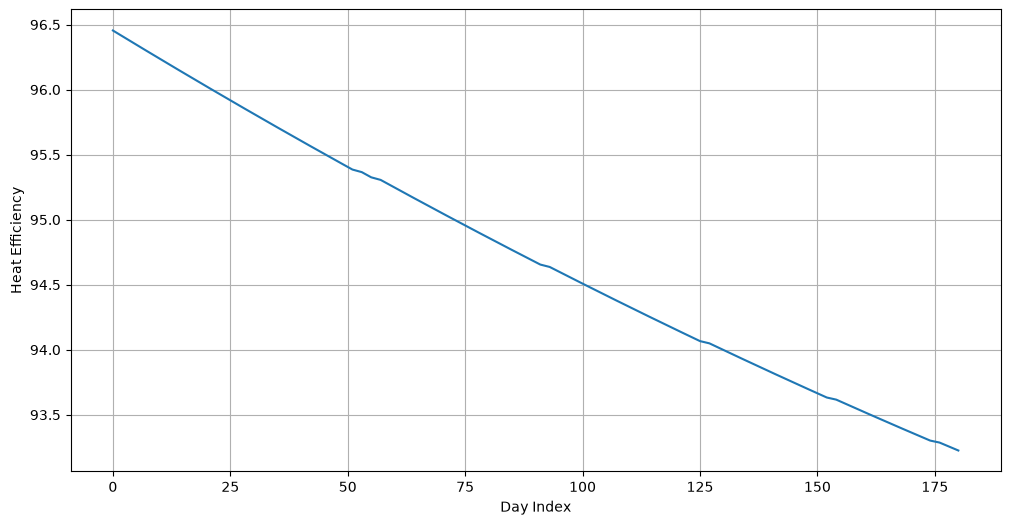

In [33]:
# seconde step: Data view
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df['day_index'], df['heat_efficiency'])
plt.xlabel('Day Index')
plt.ylabel('Heat Efficiency')
plt.grid()
plt.show()

In [34]:
# third step: warm efficiency predict
import numpy as np

y = df['heat_efficiency'].values
x = df['day_index'].values

# find the coefficients of the line with numpy
coef = np.polyfit(x , y, 1)
pred = np.polyval(coef, x)
pred


array([96.34282667, 96.3249078 , 96.30698893, 96.28907006, 96.27115119,
       96.25323232, 96.23531345, 96.21739459, 96.19947572, 96.18155685,
       96.16363798, 96.14571911, 96.12780024, 96.10988137, 96.0919625 ,
       96.07404363, 96.05612477, 96.0382059 , 96.02028703, 96.00236816,
       95.98444929, 95.96653042, 95.94861155, 95.93069268, 95.91277382,
       95.89485495, 95.87693608, 95.85901721, 95.84109834, 95.82317947,
       95.8052606 , 95.78734173, 95.76942286, 95.751504  , 95.73358513,
       95.71566626, 95.69774739, 95.67982852, 95.66190965, 95.64399078,
       95.62607191, 95.60815305, 95.59023418, 95.57231531, 95.55439644,
       95.53647757, 95.5185587 , 95.50063983, 95.48272096, 95.46480209,
       95.44688323, 95.42896436, 95.39312662, 95.37520775, 95.35728888,
       95.32145114, 95.30353228, 95.28561341, 95.26769454, 95.24977567,
       95.2318568 , 95.21393793, 95.19601906, 95.17810019, 95.16018133,
       95.14226246, 95.12434359, 95.10642472, 95.08850585, 95.07

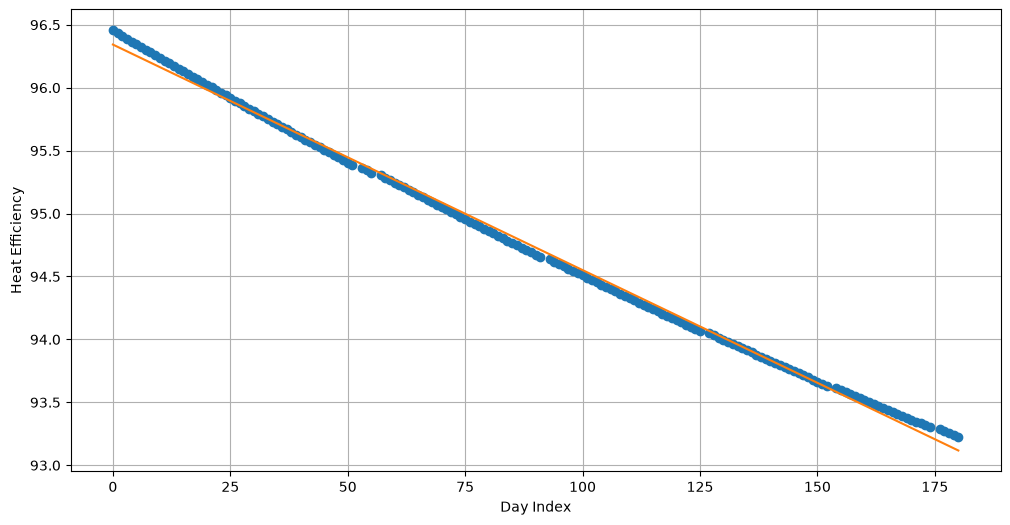

In [35]:
plt.figure(figsize=(12,6))
plt.plot(df['day_index'], df['heat_efficiency'],'o' ,label = "Real Data")
plt.plot(x, pred, label = "Calc Data")
plt.xlabel('Day Index')
plt.ylabel('Heat Efficiency')
plt.grid()
plt.show()

In [36]:
# calc r2

residuos = y - pred
ss_res = np.sum(residuos**2)
ss_tot = np.sum((y - np.mean(y))**2)

r2 = 1 - (ss_res / ss_tot)
print(r2)

0.9975040682379518
